# Programa de Capacitação de Processamento Digital de Sinais


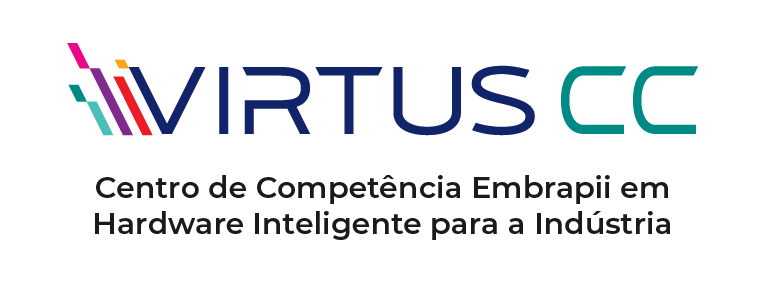


### Desenvolvido por:
-   Elmer Pimentel Farias


## Exercícios do Capítulo 1 — Processamento Digital de Sinais

Capítulo 1 do livro **Processamento Digital de Sinais** de Paulo S. R. Diniz.

## Sobre o Capítulo 1

O Capítulo 1 apresenta os conceitos básicos do Processamento Digital de Sinais (DSP), incluindo:
- Definição de sinais e sistemas
- Diferenças entre sinais contínuos e discretos
- Convolução de sinais discretos
- Teorema da Amostragem

## Objetivos Principais:
- Utilizar pacotes do Python para representar e manipular sinais discretos.
-  Implementação de uma função que receba dois sinais discretos retorne o resultado da convolução discreta entre eles.
-  Análise da complexidade computacional da implementação.
- Testar ferramentas de aceleração de código, tais como Numba e CuPy.

## Vamos utilizar bibliotecas Python para representação e manipulação de sinais discretos com implementações de Convolução

- NumPy : https://numpy.org/doc/stable/user/absolute_beginners.html
- Scipy.signal: https://docs.scipy.org/doc/scipy/reference/signal.html#convolution
- Matplotlib.pyplot: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html

Representando o Impulso Unitário

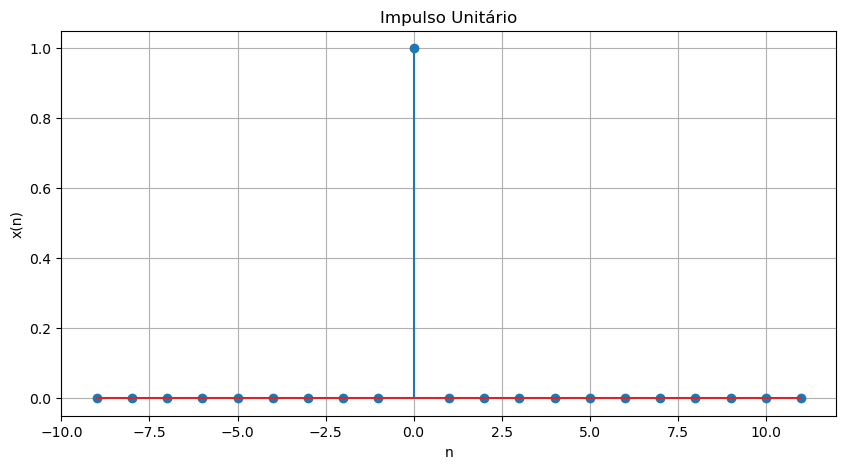

In [1]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

# Implementando o impulso unitário

n= np.arange(-9,12) #criando o vetor n de -9 a 10 em polegadas
impulse= np.where(n==0, 1, 0) #criando o impulso unitário
#np.where(condição, valor_se_verdadeiro, valor_se_falso)

# Plotando o impulso unitário
plt.figure(figsize=(10, 5))#Criando a figura e definindo o tamanho


plt.stem(n,impulse)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Impulso Unitário')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

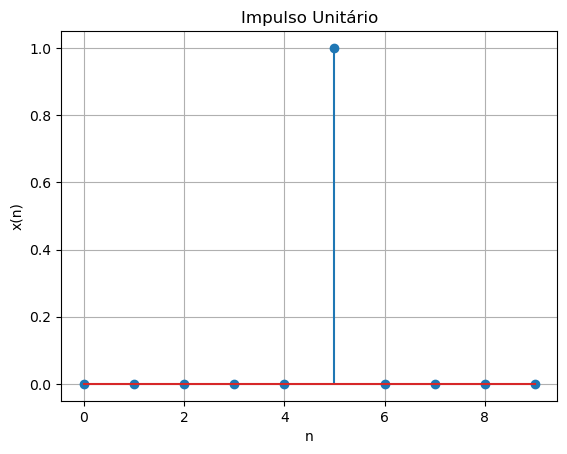

In [2]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

# Implementando uma função impulso unitário deslocado em k


def impulse(n_inicio, n_fim, n_amostras, k=0, amplitude=1.0):
    """
    Gera um sinal de impulso discreto, possivelmente deslocado.
    O deslocamento (n-k) é controlado pelo parâmetro 'posicao'.
    """
    n = np.linspace(n_inicio, n_fim, n_amostras) #cria o vetor n com 200 pontos entre n_inicio e n_fim

    rough = np.argmin(np.abs(n-k)) #encontra o índice mais próximo de posicao 
    #np.argmin= encontra o índice do menor valor 
    #np.abs= retorna o valor absoluto


    sinal = np.zeros_like(n)# Cria um vetor de zeros com o mesmo formato de n

    sinal[rough] = amplitude #define o valor do impulso na posição aproximada 
    return n, sinal

n, delta = impulse(-3, 3, 10, 0, 1.0) #chama a função para gerar o impulso unitário deslocado em k=0 com amplitude 1.0


# Plotando o impulso unitário
plt.figure()#Criando a figura e definindo o tamanho

plt.stem(delta)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Impulso Unitário')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

<span style="font-size:24px">
   Representando o Degrau Unitário
</span>


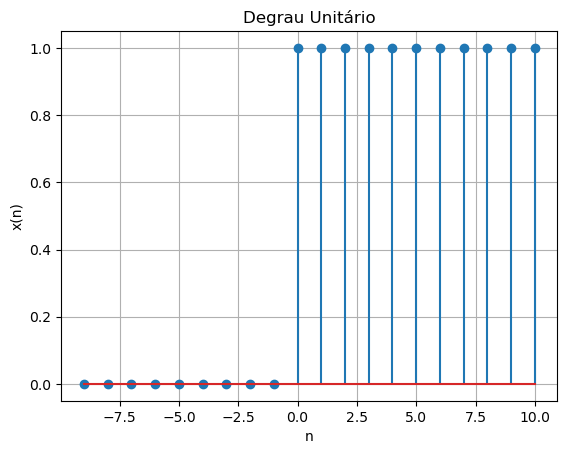

In [3]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal   

# Implementando o a função Degrau 

n= np.arange(-9,11) #criando o vetor n de -9 a 10
degrau= np.where(n>=0, 1, 0) #criando o impulso unitário
#np.where(condição, valor_se_verdadeiro, valor_se_falso)

# Plotando o Degrau Unitário
plt.figure()#Criando a figura e definindo o tamanho


plt.stem(n,degrau)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Degrau Unitário')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico


<span style="font-size:24px">
    Representando Sinais Senoidais
</span>

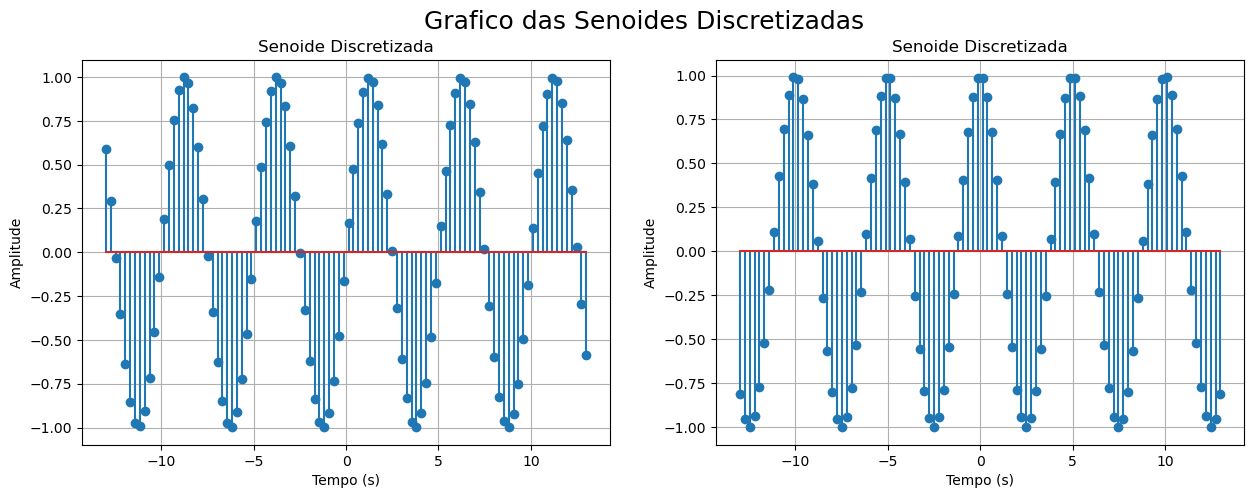

In [4]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal   

# Implementando Sinais Senoidais
N= 13 #numero de amostras
n= np.linspace(-N,N,100) #criando o vetor n de 1000 amostras
A= 1 #amplitude do sinal
t= 5 #periodo do sinal
f= 1/t #frequência do sinal

phi= 0 #fase do sinal
senoide= A * np.sin((2 * np.pi * f * n)  + phi) #criando o sinal senoidal
cossenoide= A*np.cos((2 * np.pi * f * n) + phi) #criando o sinal cossenoidal

fig, axs = plt.subplots(1,2,figsize= (15,5))
fig.suptitle('Grafico das Senoides Discretizadas', fontsize= 18)

axs[0].stem(n,senoide)
axs[0].set_title('Senoide Discretizada')
axs[0].grid(True)
axs[0].set_ylabel('Amplitude')
axs[0].set_xlabel('Tempo (s)')

axs[1].stem(n,cossenoide)
axs[1].set_title('Senoide Discretizada')
axs[1].grid(True)
axs[1].set_ylabel('Amplitude')
axs[1].set_xlabel('Tempo (s)')

plt.show()


## Usando Metodos para plotar gráficos mais eficientes com plt.subplots()  


* Cria a grade inteira de uma só vez e retorna a figura e um array de "eixos" (axes) que representam cada subplot.

### fig, axs = plt.subplots(1,2,figsize= (15,5))

-   Cria uma fig inteira e os Axes é um array do formato= [linha x coluna]
-   figsize() é o tamanho da figura inteira

*   Para acessar a figura vetorizada:

### axs[linha x coluna].func()


-   ### Equivalencia de plt. e axs.  :


| Função Global (plt) | Método do Eixo (ax) | Observação |
| :--- | :--- | :--- |
| `plt.plot()` | `ax.plot()` | Nomes iguais |
| `plt.stem()` | `ax.stem()` | Nomes iguais |
| `plt.scatter()` | `ax.scatter()` | Nomes iguais |
| `plt.bar()` | `ax.bar()` | Nomes iguais |
| `plt.title()` | `ax.set_title()` | Adiciona o prefixo `set_` |
| `plt.xlabel()` | `ax.set_xlabel()` | Adiciona o prefixo `set_` |
| `plt.ylabel()` | `ax.set_ylabel()` | Adiciona o prefixo `set_` |
| `plt.grid()` | `ax.grid()` | Nomes iguais |
| `plt.legend()` | `ax.legend()` | Nomes iguais |

<span style="font-size:24px">
    Realizar a Convolução em python, tentar refazer a função np.convolve da biblioteca NumPy
</span>


A convolução em tempo discreto é uma operação essencial para analisar sistemas lineares e invariantes no tempo (LTI). Ela permite determinar a saída de um sistema para qualquer entrada, conhecendo apenas a resposta ao impulso do sistema.

A convolução de dois sinais discretos $x[n]$ e $h[n]$ é definida por:

$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n - k]
$$

Onde:
- $x[n]$: sinal de entrada
- $h[n]$: resposta ao impulso do sistema
- $y[n]$: saída do sistema

## Implementação com Vetores Finitos em Python

Como lidamos com vetores de tamanho finito em Python, a fórmula costuma ser reescrita como:

$$
y[n] \;=\; \sum_{k=0}^{M-1} x[k]\;\cdot\;h[n - k]
$$


## Dimensões dos Vetores

- \(x\) tem tamanho \(M\)  
- \(h\) tem tamanho \(N\)  
- \(y\) terá tamanho \(M + N - 1\)  


Esse bloco de código mostra como implementar a convolução discreta em Python, aplicar a operação a sinais de exemplo e visualizar os resultados, incluindo o eixo de tempo correto para cada gráfico.

1° Convolução temos: 

Fórmula Geral da Convolução Discreta
A convolução discreta de dois sinais ( x(n) ) e ( h(n) ) é definida por:

$$ y(n) = (x * h)(n) = \sum_{k=-\infty}^{\infty} x(k) \cdot h(n - k) $$

No caso de vetores finitos de tamanho ( M ) e ( N ):

$$ y[n] = \sum_{k=0}^{M-1} x[k] \cdot h[n - k] $$

Convolução de ( x(n) ) com o Impulso Unitário ( \delta(n) )
Quando ( h(n) = \delta(n) ), temos:

$$ y(n) = \sum_{k=-\infty}^{\infty} x(k) \cdot \delta(n - k) $$

Pela propriedade do impulso unitário:

$$ y(n) = x(n) $$

Ou seja, a saída da convolução de qualquer sinal com o impulso unitário é o próprio sinal.


2° Convolução temos:

$$ y(n) = (x * h)(n) = \sum_{k=-\infty}^{\infty} x(k) \cdot h(n - k) $$

Portanto, a convolução fica:

$$ y(n) = \sum_{k=-\infty}^{\infty} \sin(k) \cdot e^{-(n-k)} $$

Como trabalhamos com vetores finitos de tamanho ( N ), a soma é limitada ao intervalo das amostras:

$$ y[n] = \sum_{k=0}^{N-1} x[k] \cdot h[n - k] $$

Ou, substituindo as funções:

$$ y[n] = \sum_{k=0}^{N-1} \sin(n_k) \cdot \exp(-(n_n - n_k)) $$

Onde ( n_k ) e ( n_n ) são os valores do vetor de amostras.

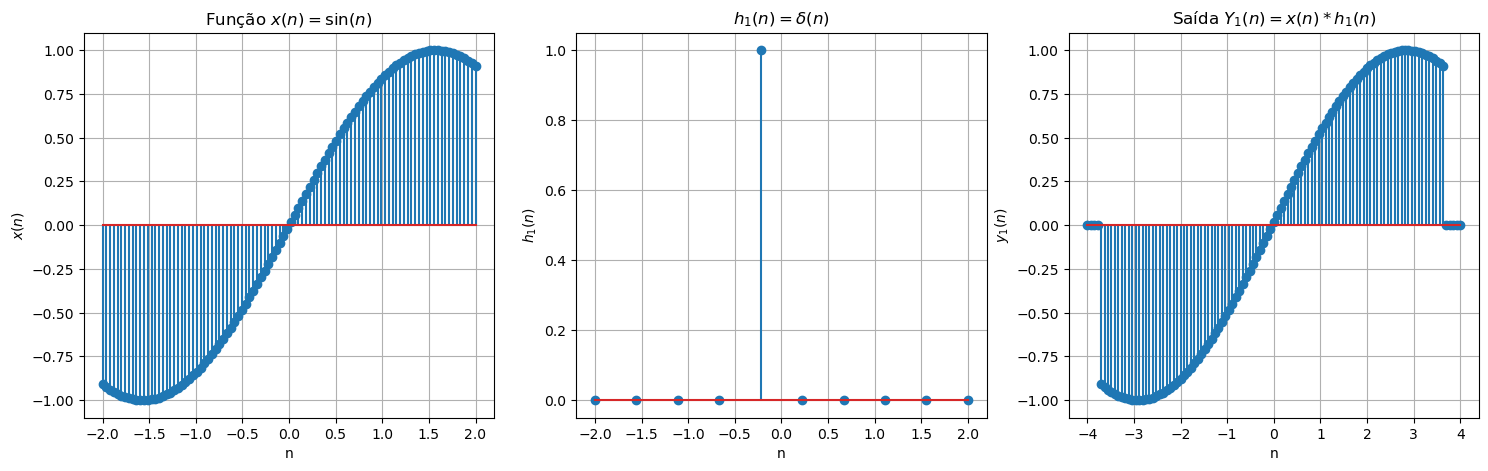

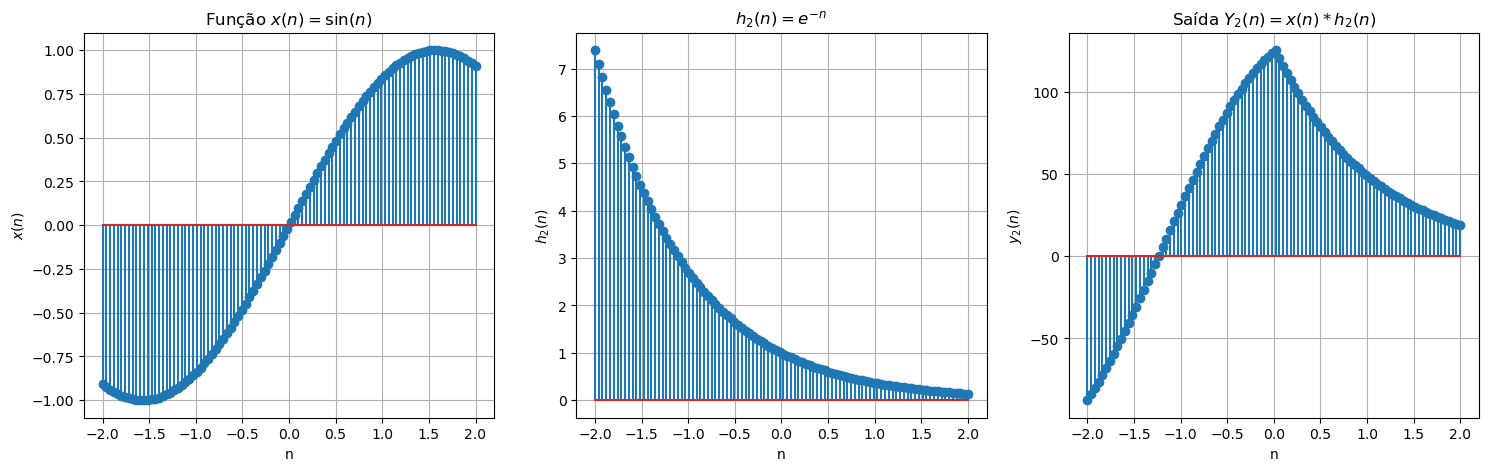

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

#Neste exemplo vamos implementar apenas o mode Full da convolução, que é o mais comum em aplicações de sinais discretos.

def conv(x, h , mode="full"):


    """
    Realiza a convolução entre dois sinais discretos x e h.
    O parâmetro 'mode' controla o tipo de convolução:
    - 'full': Convolução completa
    - 'valid': Convolução válida
    - 'same': Convolução com o mesmo tamanho do sinal de entrada x
    """


    #definir o tamanho dos sinais e onde havera convolução
    M = len(x)  # Tamanho do sinal x
    N = len(h)  # Tamanho do sinal h
    y= np.zeros(M + N - 1)  # Cria um vetor de zeros para armazenar o resultado da convolução com o tamanho (M + N - 1)

    for n in range(M + N - 1):#Laço para percorrer o tamanho (M + N - 1)
        for k in range(M): #dentro de outro laço para percorrer o tamanho de y(vetor de zeros da saida)
            if 0 <= n - k < N: # condição para verificar se o índice n-k está dentro dos limites do vetor y
                y[n] += x[k] * h[n - k]  # Realiza a convolução
    if mode == "full":  # Se o modo for 'full', retorna a convolução completa
        # A saída terá tamanho M + N - 1, que é o tamanho máximo da convolução
        return y

    elif mode == "same":  # Se o modo for 'same', retorna apenas a parte válida da convolução
        # Retorna a parte central da convolução, que tem o mesmo tamanho que o sinal de entrada x
        # A saida vai ter o mesmo numero de pontos que a entrada x(n)
        
        n_elements_cutted= (len(y) - len(x))  # Calcula o número de elementos a serem cortados
        centralized_idx = n_elements_cutted // 2  # Calcula o índice central para cortar o inicio

        #a divisao inteira // é usada para garantir que o índice seja um número inteiro e caso for impar, o valor central será o mais próximo do meio

        y = y[centralized_idx:centralized_idx + len(x)]  # Corta a convolução para manter o tamanho do sinal de entrada x
        #corta o array [inicio:final+1] para manter o tamanho do sinal de entrada x
        return y
    elif mode == "valid":  # Se o modo for 'valid', retorna apenas a parte válida da convolução
        # Retorna a parte válida da convolução, que é a parte onde ambos os sinais se sobrepõem completamente
        start= N-1
        end= M
        y=y[start:end]  # Corta a convolução para manter apenas a parte válida
        return y
    else :
        raise ValueError("Modo inválido. Use 'full', 'same' ou 'valid'.")  
                  


# --- Sinais de Entrada ---

amostras = np.linspace(-2, 2, 100)
x_n = np.sin(amostras)
exp = np.exp(-amostras)

# --- Figura 1: Convolução com o Impulso ---
plt.figure(figsize=(18, 5))
# Plotando a função x(n)
plt.subplot(1, 3, 1)
plt.stem(amostras, x_n)
plt.title('Função $x(n) = \sin(n)$')
plt.xlabel('n')
plt.ylabel('$x(n)$')
plt.grid(True)

# Gerando e plotando o impulso h(n)
n_impulse, delta = impulse(n_inicio=-2, n_fim=2, n_amostras=10, k=0, amplitude=1.0)
plt.subplot(1, 3, 2)
plt.stem(n_impulse, delta)
plt.title('$h_1(n) = \delta(n)$')
plt.xlabel('n')
plt.ylabel('$h_1(n)$')
plt.grid(True)

# Calculando e plotando a convolução y1(n)
conv1 = conv(x_n, delta, mode="full")
# CORREÇÃO: Cria o vetor de tempo para a convolução 'full'
start_n1 = amostras[0] + n_impulse[0]
end_n1 = amostras[-1] + n_impulse[-1]
n_conv1 = np.linspace(start_n1, end_n1, len(conv1))

plt.subplot(1, 3, 3)
plt.stem(n_conv1, conv1)
plt.title('Saída $Y_1(n) = x(n) * h_1(n)$')
plt.xlabel('n')
plt.ylabel('$y_1(n)$')
plt.grid(True)

# --- Figura 2: Convolução com a Exponencial ---
plt.figure(figsize=(18, 5))

# Plotando a função x(n) novamente
plt.subplot(1, 3, 1)
plt.stem(amostras, x_n)
plt.title('Função $x(n) = \sin(n)$')
plt.xlabel('n')
plt.ylabel('$x(n)$')
plt.grid(True)

# Gerando e plotando a exponencial h2(n)

plt.subplot(1, 3, 2)
plt.stem(amostras, exp)
plt.title('$h_2(n) = e^{-n}$')
plt.xlabel('n')
plt.ylabel('$h_2(n)$')
plt.grid(True)

# Calculando e plotando a convolução y2(n)

conv2 = conv(x_n, exp, mode="same") #Realizando a segunda convolução entre x(n) e h2(n) no modo same

n_conv2 = amostras  # No modo 'same', o eixo de tempo do resultado é o mesmo do primeiro sinal.

plt.subplot(1, 3, 3)
plt.stem(n_conv2, conv2)
plt.title('Saída $Y_2(n) = x(n) * h_2(n)$')
plt.xlabel('n')
plt.ylabel('$y_2(n)$')
plt.grid(True)

"""
## Teoria da Amostragem (Nyquist)

A **Teoria da Amostragem de Nyquist-Shannon** é o princípio fundamental que nos permite digitalizar um sinal do mundo real (analógico) sem perder suas informações essenciais.

### A Regra Principal

Para reconstruir perfeitamente um sinal contínuo, a **frequência de amostragem** ($f_{amostragem}$) deve ser, no mínimo, **duas vezes maior** que a **frequência máxima** ($f_{máxima}$) contida no sinal original.

A fórmula é:

$$f_{amostragem} > 2 \cdot f_{máxima}$$

### O Problema do "Aliasing"

Se a regra não for seguida (subamostragem), ocorre o **aliasing**: o sinal digitalizado mostra frequências "falsas" e mais baixas que não existem no sinal original.

**Analogia:** É o mesmo efeito que faz as rodas de um carro em um filme parecerem girar lentamente ou para trás. A câmera (que amostra a uma certa taxa de quadros) não é rápida o suficiente para capturar o movimento real.

### Retornando ao Sinal Original (Interpolação)

Se a regra de Nyquist for respeitada, é matematicamente possível reconstruir o sinal analógico original perfeitamente a partir de suas amostras.

Isso é feito através da **fórmula de interpolação de Whittaker-Shannon**, que utiliza uma soma infinita de funções `sinc` ponderadas e deslocadas. Cada amostra `x[n]` contribui para a reconstrução do sinal contínuo `x(t)`:

$$x(t) = \sum_{n=-\infty}^{\infty} x[n] \cdot \operatorname{sinc}\left(\frac{t - nT_s}{T_s}\right)$$

Onde:
* `x(t)` é o sinal contínuo reconstruído.
* `x[n]` são os valores das amostras digitais.
* `T_s` é o período de amostragem (1 / f_amostragem).
* A função `sinc(y)` é definida como `sin(πy) / (πy)`.

Essencialmente, cada impulso (amostra) é substituído por uma função `sinc`, e a soma de todas essas funções `sinc` recria a forma de onda original.
"""


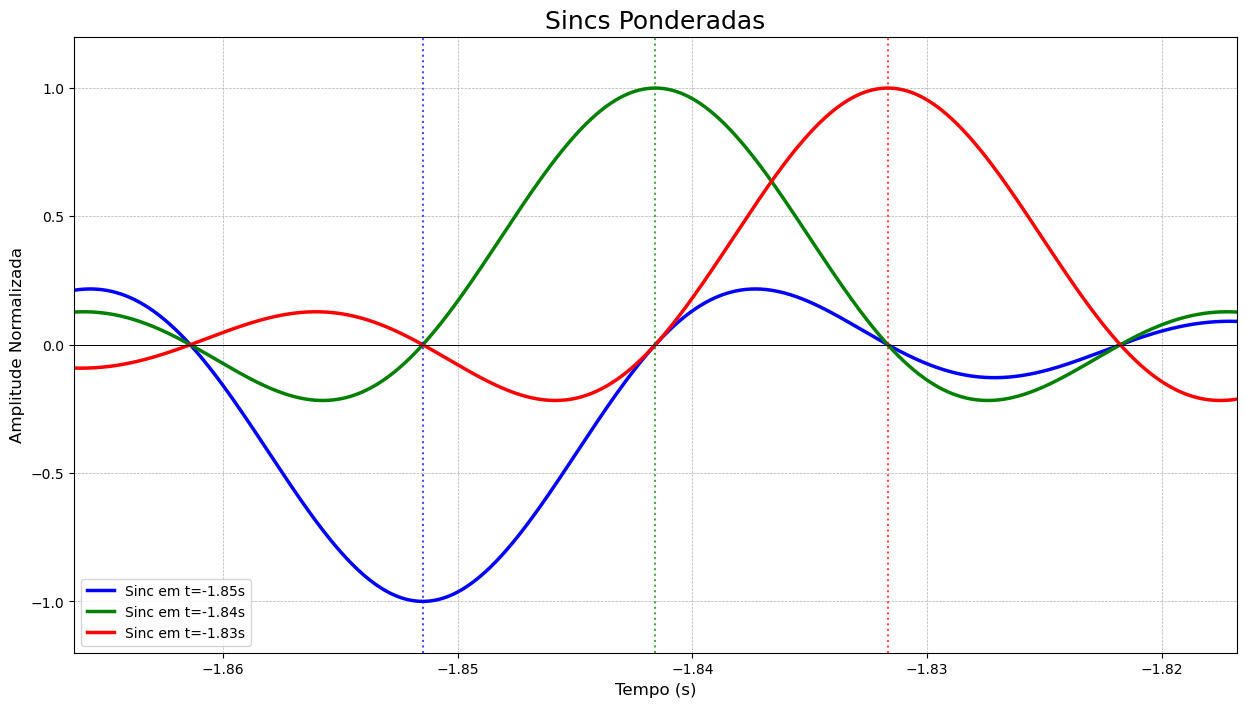

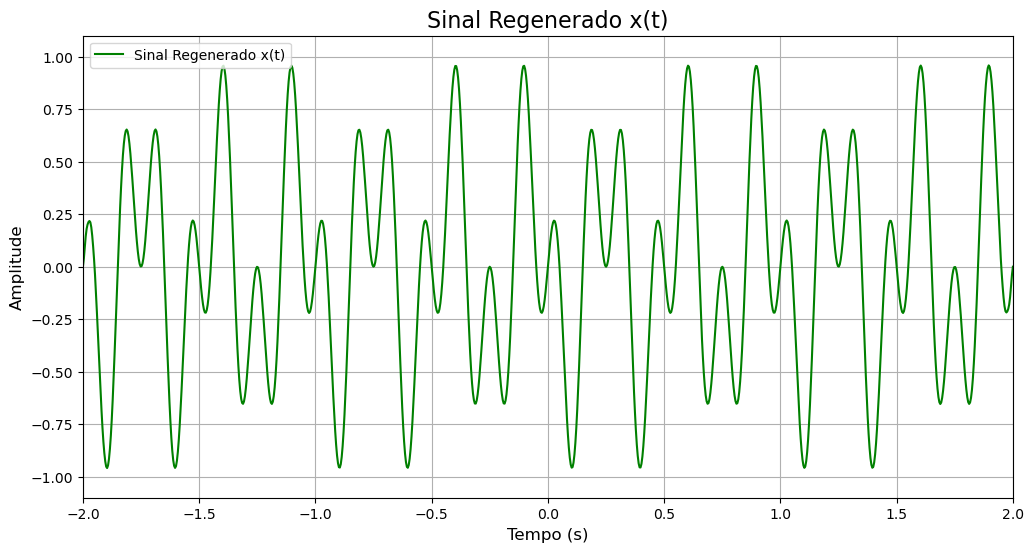

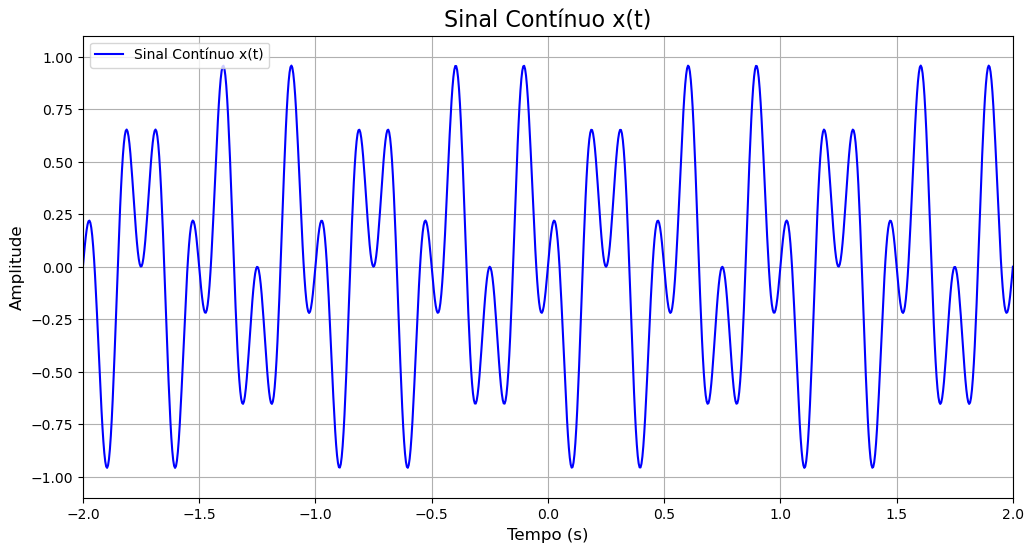

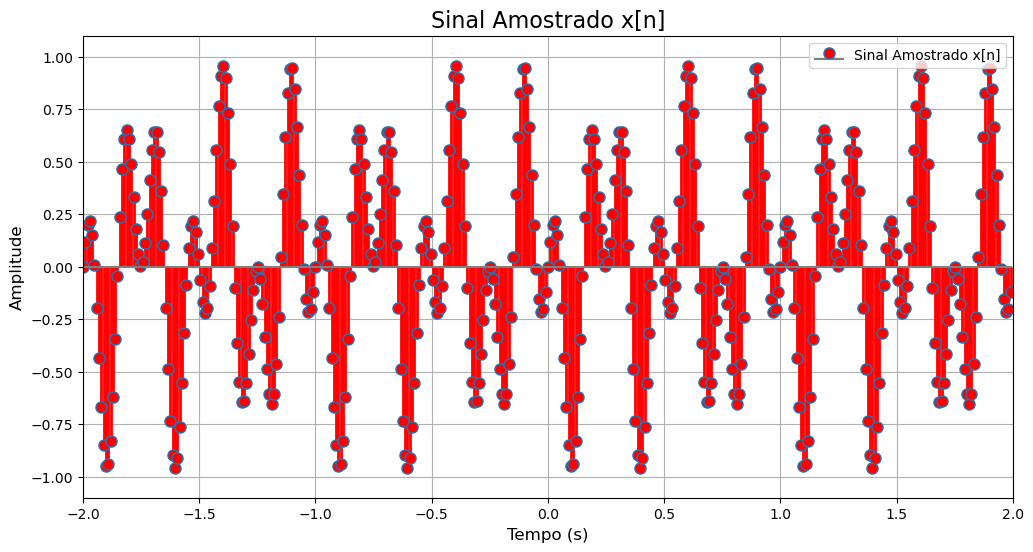

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# --- Parâmetros do Sinal com Frequências Ajustadas para Melhor Visualização ---
N = 1000  # numero de amostras
start = -2.0  # início do vetor t
end = 2.0  # fim do vetor t

# Vetor de tempo para o sinal contínuo x(t)
t = np.linspace(start, end, N)

A = 1  # amplitude do sinal
phi = 0  # fase do sinal


f1 = 2  # frequência do sinal 2 em Hz
f2 = 5  # frequência do sinal 5 em Hz

f_max = max(f1, f2)  # Frequência máxima do sinal

# Sinal x(t) 
x_t = A * np.sin(2 * np.pi * f1 * t + phi) * (A * np.cos(2 * np.pi * f2 * t + phi))

f_nyquist = 2 * f_max  # Frequência de Nyquist
f_s = (10.1) * f_nyquist   # Frequência de amostragem
t_s = 1 / f_s         # Período de amostragem

# Vetor de tempo para o sinal amostrado x[n]
n = np.arange(start, end, t_s)

# Sinal amostrado x[n]
x_n = A * np.sin(2 * np.pi * f1 * n + phi) * (A * np.cos(2 * np.pi * f2 * n + phi))

def signal_regen(x_n,n_amostras,ts,t): #x_n= X(n), ts_0= t_s, x_n= n*ts, ts= t_s, t= t, n_amostras = n

    signal = np.zeros_like(t)  # Inicializa o sinal vetor com zeros

    # Calcula o sinc para cada amostra

    for i in range (len(x_n)):# percorre o vertor x_n para cada posição i do vetor

        x_n_i = x_n[i]  # Varre o vetor x_n para pegar o valor da i-ésima amostra
        ts_x_n = n_amostras[i]  # Para cada i , calcula a i-esima amostra do periodo de amostragem

        # X(i) e (i)*(Ts) são os valores do sinal amostrado e do tempo amostrado, respectivamente


        # Calcula o sinc para cada i-esima amostra e soma as sincs ponderadas
        signal += x_n_i * np.sinc((t - ts_x_n) / ts)
    return signal



Rx_t = signal_regen(x_n,n, t_s,t)  # Chama a função para regenerar o sinal contínuo a partir do sinal amostrado

# a função signal_regen recebe o sinal amostrado x_n, o vetor de tempo n, o período de amostragem t_s e o vetor de tempo t para gerar o sinal contínuo Rx_t

#==============================================================
plt.figure(figsize=(15, 8))

# --- Definindo a área de Zoom ---
# Vamos focar em 3 amostras a partir do índice 15 do seu vetor 'n'
indice_de_inicio_do_zoom = 15
numero_de_curvas = 3

# Ponto central para o zoom
tempo_central = n[indice_de_inicio_do_zoom + 1] 
largura_do_zoom = t_s * 5
zoom_start = tempo_central - largura_do_zoom / 2
zoom_end = tempo_central + largura_do_zoom / 2

# --- Vetor de tempo de ALTA RESOLUÇÃO (a solução para as curvas 'feias') ---
t_alta_resolucao = np.linspace(zoom_start, zoom_end, 2000)

# Cores para as 3 curvas
colors = ['blue', 'green', 'red']

# --- Loop para plotar as 3 sincs escolhidas ---
for i in range(numero_de_curvas):
    # Índice da amostra atual que vamos usar de 'x_n' e 'n'
    indice_atual = indice_de_inicio_do_zoom + i

    # Pegando os valores diretamente dos seus vetores 'x_n' e 'n'
    valor_da_amostra = x_n[indice_atual]
    tempo_da_amostra = n[indice_atual]
    
    if valor_da_amostra == 0:
        continue
        
    # Usando o t_alta_resolucao para o cálculo da curva suave
    sinc_individual = np.sign(valor_da_amostra) * np.sinc((t_alta_resolucao - tempo_da_amostra) / t_s)
    
    # Plotando com o t_alta_resolucao no eixo X
    plt.plot(t_alta_resolucao, sinc_individual, linestyle='-', linewidth=2.5, color=colors[i], label=f'Sinc em t={tempo_da_amostra:.2f}s')

# --- Configurações finais do gráfico ---
plt.title('Sincs Ponderadas', fontsize=18)
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Amplitude Normalizada', fontsize=12)
plt.xlim(zoom_start, zoom_end)
plt.ylim(-1.2, 1.2)
plt.legend(loc='lower left', fontsize='medium')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.axhline(0, color='black', linewidth=0.7)
# Adicionando linhas verticais nos tempos exatos das amostras
for i in range(numero_de_curvas):
    plt.axvline(n[indice_de_inicio_do_zoom + i], color=colors[i], linestyle=':', alpha=0.7)
plt.show()
#==============================================================


# --- Gráfico do Sinal Regenerado ---
plt.figure(figsize=(12, 6)) 
plt.plot(t, Rx_t, label='Sinal Regenerado x(t)', color='green')
plt.title('Sinal Regenerado x(t)', fontsize=16)
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.xlim(start, end)
plt.ylim(-A * 1.1, A * 1.1)
plt.legend()
plt.grid(True)
plt.show()  # Mostra o gráfico do sinal regenerado

# --- Gráfico de x(t) ---
plt.figure(figsize=(12, 6))
plt.plot(t, x_t, label='Sinal Contínuo x(t)', color='blue')
plt.title('Sinal Contínuo x(t)', fontsize=16)
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.xlim(start, end)
plt.ylim(-A * 1.1, A * 1.1)
plt.legend()
plt.grid(True)


# --- Gráfico de x[n] ---
plt.figure(figsize=(12, 6))
# Usando markerfmt e linefmt para customizar o gráfico de stem
markerline, stemlines, baseline = plt.stem(n, x_n, label='Sinal Amostrado x[n]', basefmt="gray")
plt.setp(markerline, 'markerfacecolor', 'red', 'markersize', 8)
plt.setp(stemlines, 'color', 'red', 'linewidth', 2)

plt.title('Sinal Amostrado x[n]', fontsize=16)
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.xlim(start, end)
plt.ylim(-A * 1.1, A * 1.1)
plt.legend()
plt.grid(True)


## Experimento 1.3

### Objetivo

O objetivo deste experimento é simular a digitalização de um sinal analógico composto, introduzir uma perturbação na forma de ruído aditivo e observar os efeitos dessa corrupção no domínio do tempo.

### Descrição do Sinal

O sinal de base para este experimento é um sinal contínuo no tempo, $x(t)$, composto pela soma de duas cossenoides com amplitudes e frequências distintas. A expressão matemática que define o sinal é:

$$x(t) = 5\cos(2\pi \cdot 5t) + 2\cos(2\pi \cdot 50t)$$

Este sinal possui dois componentes principais:
1.  Um componente de baixa frequência com amplitude **5.0** e frequência de **5 Hz**.
2.  Um componente de alta frequência com amplitude **2.0** e frequência de **50 Hz**.

### Parâmetros de Simulação

Para a simulação digital, foram adotados os seguintes parâmetros:

* **Frequência de Amostragem ($F_s$)**: O sinal contínuo $x(t)$ foi amostrado a uma taxa de **1000 amostras por segundo** (1000 Hz). Isso resulta em um período de amostragem $T_s = 1/F_s = 0.001$ segundos (1 ms).

* **Corrupção por Ruído**: Após a geração do sinal digital limpo, ele é corrompido por uma pequena quantidade de ruído para simular um cenário mais realista, como o de uma medição com interferência. O sinal ruidoso, $y(t)$, é o resultado da soma do sinal original com o ruído.

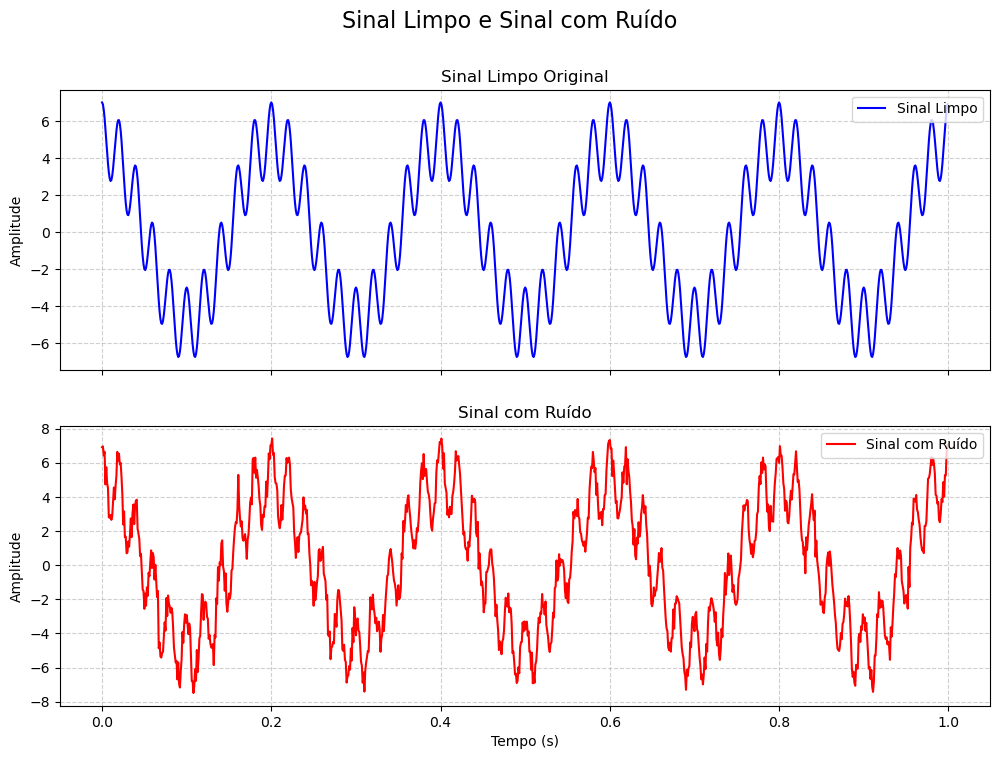

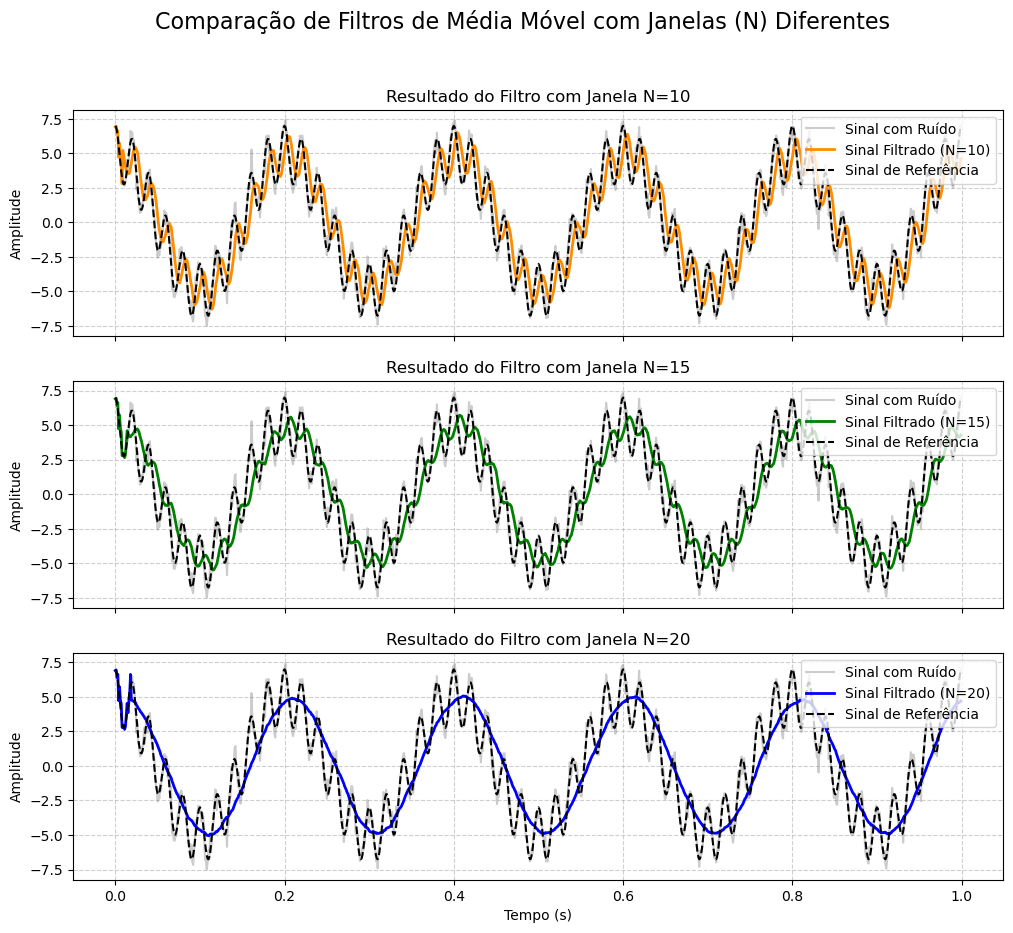

In [7]:
import numpy as np  
import matplotlib.pyplot as plt  
import scipy.signal as signal  

#  Definição dos Parâmetros dos Sinais 

# Parâmetros para o primeiro sinal 
amplitude1 = 5.0
freq_1 = 5.0

# Parâmetros para o segundo sinal 
amplitude2 = 2.0
freq_2 = 50.0


Fs = 1000      # Frequência de amostragem (em Hz): 1000 amostras por segundo.
Ts = 1/Fs      # Período de amostragem: o intervalo de tempo entre cada amostra.
time_vector = np.arange(0, 1, Ts)  # Cria um vetor de tempo, de 0 até (quase) 1 segundo.

#  Geração dos Sinais e do Ruído 

# Criação do primeiro sinal cosseno.
signal1 = amplitude1 * np.cos(2 * np.pi * freq_1 * time_vector)

# Criação do segundo sinal cosseno.
signal2 = amplitude2 * np.cos(2 * np.pi * freq_2 * time_vector)

# Geração de um ruído gaussiano (aleatório, com distribuição normal) com média 0 e desvio padrão 0.5.
noise = np.random.normal(0, 0.5, signal1.shape)

# Soma dos dois sinais para criar o sinal limpo composto de duas senoides
clear_signal = signal1 + signal2

# Adição do ruído ao sinal limpo 
noise_signal = clear_signal + noise


# Cria uma figura com 2 subplots para os sinais com ruido e sem ruido
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Sinal Limpo e Sinal com Ruído', fontsize=16)

# Plot no primeiro eixo (o de cima)
axs[0].plot(time_vector, clear_signal, color='blue', label='Sinal Limpo')
axs[0].set_title('Sinal Limpo Original')
axs[0].set_ylabel('Amplitude')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot no segundo eixo (o de baixo)
axs[1].plot(time_vector, noise_signal, color='red', label='Sinal com Ruído')
axs[1].set_title('Sinal com Ruído')
axs[1].set_ylabel('Amplitude')
axs[1].set_xlabel('Tempo (s)')
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.6)


# Define a função que aplica o filtro de média móvel, baseada na equação de diferença finita, demonstrada no livro
def reduce_noise(signal, N):
    new_signal = np.copy(signal)
    for n in range(N-1, len(signal)):
        new_signal[n] = np.mean(signal[n-N+1:n+1])
    return new_signal


# Aplica o filtro de média móvel com três tamanhos de janela diferentes. Para cada N.
N_20 = reduce_noise(noise_signal, 20)
N_15 = reduce_noise(noise_signal, 15)
N_10 = reduce_noise(noise_signal, 10)

# Cria uma nova figura com 3 subplots (empilhados), compartilhando os eixos X e Y.
# sharex e sharey garantem que a escala de tempo e amplitude seja a mesma em todos, para uma comparação justa.
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)
fig.suptitle('Comparação de Filtros de Média Móvel com Janelas (N) Diferentes', fontsize=16)

#  Subplot 1: Filtro com N=10 
axs[0].set_title('Resultado do Filtro com Janela N=10')
# Plota o sinal ruidoso no fundo como contexto.
axs[0].plot(time_vector, noise_signal, color='gray', alpha=0.4, label='Sinal com Ruído')
# Plota o sinal filtrado.
axs[0].plot(time_vector, N_10, color='darkorange', linewidth=2, label='Sinal Filtrado (N=10)')
# Plota o sinal limpo como referência.
axs[0].plot(time_vector, clear_signal, 'k--', linewidth=1.5, label='Sinal de Referência')
axs[0].set_ylabel('Amplitude')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Filtro com N=15 
axs[1].set_title('Resultado do Filtro com Janela N=15')
axs[1].plot(time_vector, noise_signal, color='gray', alpha=0.4, label='Sinal com Ruído')
axs[1].plot(time_vector, N_15, color='green', linewidth=2, label='Sinal Filtrado (N=15)')
axs[1].plot(time_vector, clear_signal, 'k--', linewidth=1.5, label='Sinal de Referência')
axs[1].set_ylabel('Amplitude')
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.6)

# Subplot 3: Filtro com N=20 
axs[2].set_title('Resultado do Filtro com Janela N=20')
axs[2].plot(time_vector, noise_signal, color='gray', alpha=0.4, label='Sinal com Ruído')
axs[2].plot(time_vector, N_20, color='blue', linewidth=2, label='Sinal Filtrado (N=20)')
axs[2].plot(time_vector, clear_signal, 'k--', linewidth=1.5, label='Sinal de Referência')
axs[2].set_ylabel('Amplitude')
axs[2].set_xlabel('Tempo (s)') # Adiciona o rótulo do eixo X apenas no último gráfico.
axs[2].legend(loc='upper right')
axs[2].grid(True, linestyle='--', alpha=0.6)

# Exibe todas as figuras geradas.
plt.show()

## Ferramentas de Aceleração de Código

* #### Numba: https://numba.readthedocs.io/en/stable/index.html
    

    -   A Numba é uma biblioteca de código aberto para Python que funciona como um compilador Just-In-Time (JIT). De forma simples,
     ela traduz um subconjunto do código Python e NumPy para código de máquina otimizado no momento da execução, resultando em um aumento significativo de velocidade.
    
    -   O principal objetivo da Numba é acelerar funções que realizam muitos cálculos numéricos, como as que contêm laços de repetição (for, while) e operações matemáticas com arrays. Ela é especialmente poderosa quando usada em conjunto com a biblioteca NumPy.

    -   Numba usa decoradores tipo @jit,  @njit (mais famosos), analisando o bytecode dessa função "decorada". E se especificar o tipos de dados dos argumentos da função ajuda bastante na otimização pois a natureza do Python, como linguagem de alto nivel, onde as variaveis podem conter varios tipo. Assim o Numba gera um codigo de maquina muito mais eficiente

    -   Numba utiliza o LLVM(Low-Level Virtual Machine) que traduz o bytecode da função em um codigo de maquina otimizado para a CPU especifica.

    -   IMPORTANTE: O Numba armazena em cache o codigo de maquina gerado, entao na primeira chamada pode-se demorar mais, entretanto nas chamadas subsequentes com os mesmos tipos de argumentos o codigo compilado e já otimizado é executado diretamente da cache.

* ### Decoradores NUMBA (@jit, @njit):

    -   O decorador njit é na verdade o mesmo de jit, porém recebendo o argumento @jit(nopython=True), esse argumento é fundamental para otimizar o desempenho do @jit pois ele instrui o Numba a compilar a função inteiramente sem a intervenção do interpretador do Python. Em caso de haver uma operação que o Numba não consiga otimizar (como o uso de listas heterogêneas ou dicionários complexos do Python), ocorrerá um Error. Logo, o @njit é um atalho para @jit(nopython=True).

    -   * Outros argumentos para @jit:

        - (cache=True): Salva o resultado da compilação em um arquivo no seu disco (__pycache__). Na próxima vez que você rodar o script, se a função não tiver sido alterada, o Numba carregará a versão já compilada do arquivo em vez de recompilar.


        -  (parallel=True): Habilita as otimizações de paralelismo automático do Numba. Para ser usado em conjunto com prange()[trocamos o range por prange para o loop externo] para acelerar loops em máquinas com múltiplos núcleos.
            Condição Crucial: 
                

        -  (fastmath=True) : Permite que o compilador use otimizações matemáticas de ponto flutuante que são mais rápidas, mas que podem violar alguns padrões estritos de precisão da norma IEEE 754. Pode dar um ganho de velocidade extra (10-20%) em código com muitas operações de ponto flutuante (divisão, funções trigonométricas, etc.). Entretanto, isso implica talvez perder mais precisão em niveis mais baixos de abstração.

  


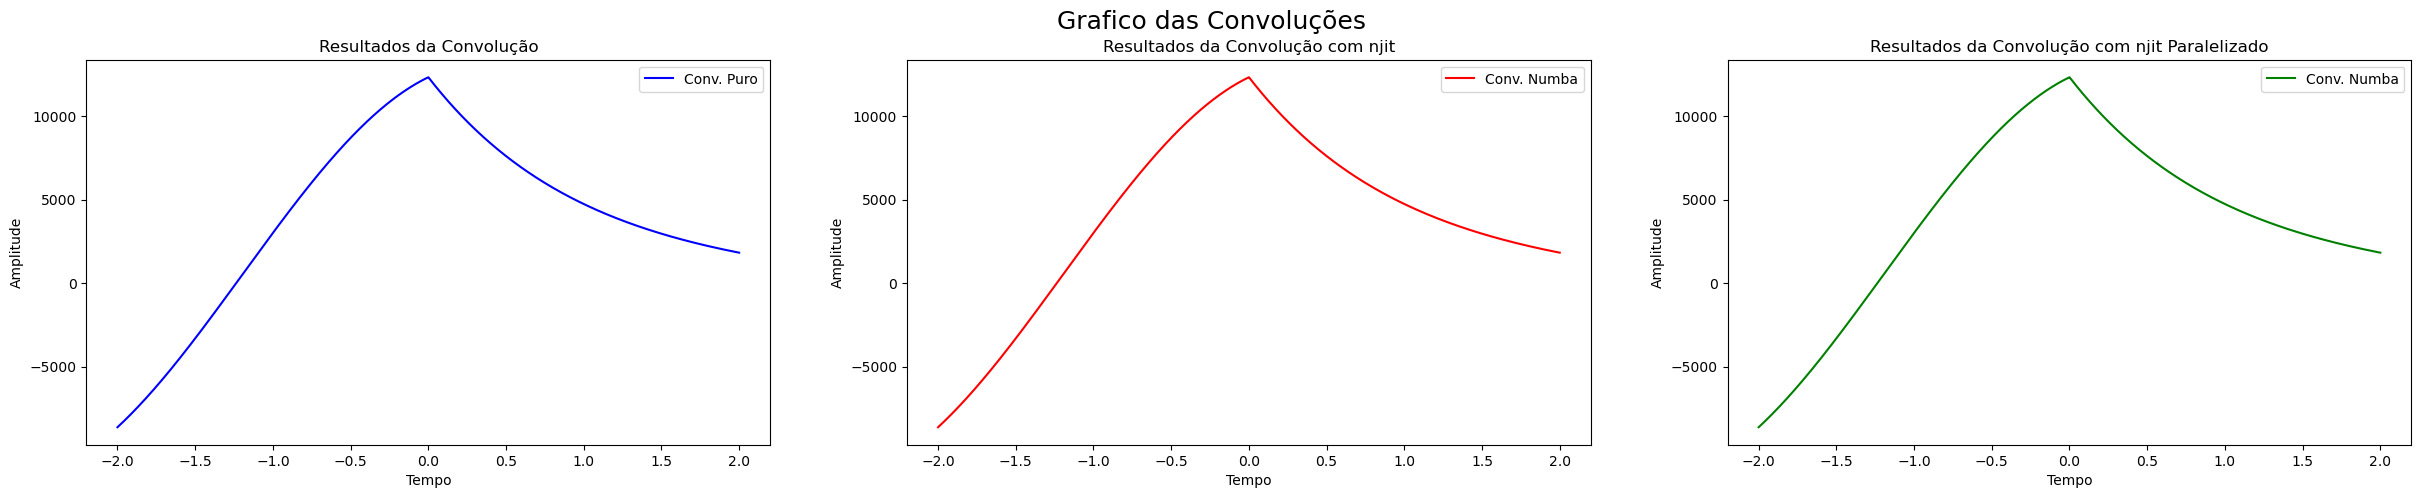

Executando a Convolução dos sinais X(n) e H(n) com Python puro...

Tempo de execução (Python puro): 28.297956 segundos

Executando a Convolução dos sinais X(n) e H(n) com o decorador @njit...

Tempo de execução (Numba): 0.174101 segundos

Executando a Convolução dos sinais X(n) e H(n) com o decorador @njit PARALELIZADO...

Tempo de execução (Numba): 0.015780 segundos

A convolução com @njit é mais eficente 162.537252 x

A convolução com @njit Paralelizado é mais eficente 162.537252 x


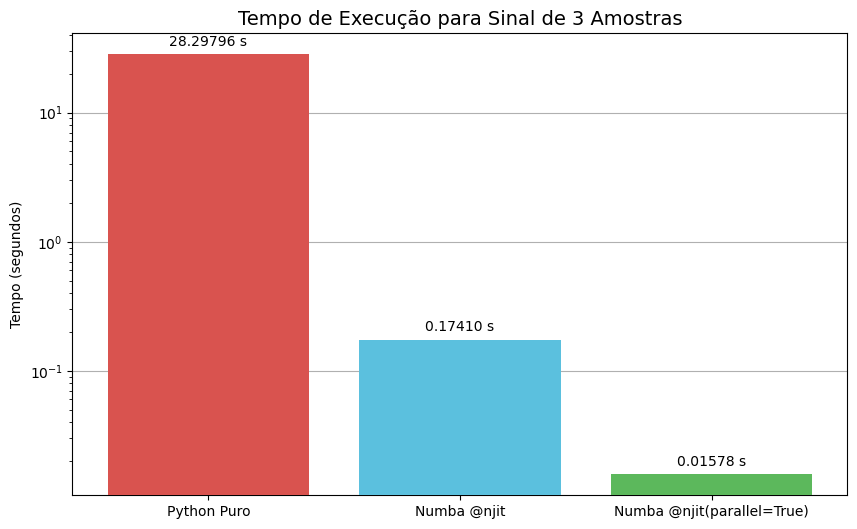

In [8]:
import numpy as np
import time
from numba import njit, jit , vectorize , prange

# Funções de Convolução baseadas com realizadas no Jupyter acima.

def conv_python_puro(x, h , mode="full"):
    #definir o tamanho dos sinais e onde havera convolução
    M = len(x)  # Tamanho do sinal x
    N = len(h)  # Tamanho do sinal h
    y= np.zeros(M + N - 1)  # Cria um vetor de zeros para armazenar o resultado da convolução com o tamanho (M + N - 1)

    for n in range(M + N - 1):#Laço para percorrer o tamanho (M + N - 1)
        for k in range(M): #dentro de outro laço para percorrer o tamanho de y(vetor de zeros da saida)
            if 0 <= n - k < N: # condição para verificar se o índice n-k está dentro dos limites do vetor y
                y[n] += x[k] * h[n - k]  # Realiza a convolução
    if mode == "full":  # Se o modo for 'full', retorna a convolução completa
        # A saída terá tamanho M + N - 1, que é o tamanho máximo da convolução
        return y

    elif mode == "same":  # Se o modo for 'same', retorna apenas a parte válida da convolução
        # Retorna a parte central da convolução, que tem o mesmo tamanho que o sinal de entrada x
        # A saida vai ter o mesmo numero de pontos que a entrada x(n)
        
        n_elements_cutted= (len(y) - len(x))  # Calcula o número de elementos a serem cortados
        centralized_idx = n_elements_cutted // 2  # Calcula o índice central para cortar o inicio

        #a divisao inteira // é usada para garantir que o índice seja um número inteiro e caso for impar, o valor central será o mais próximo do meio

        y = y[centralized_idx:centralized_idx + len(x)]  # Corta a convolução para manter o tamanho do sinal de entrada x
        #corta o array [inicio:final+1] para manter o tamanho do sinal de entrada x
        return y
    elif mode == "valid":  # Se o modo for 'valid', retorna apenas a parte válida da convolução
        # Retorna a parte válida da convolução, que é a parte onde ambos os sinais se sobrepõem completamente
        start= N-1
        end= M
        y=y[start:end]  # Corta a convolução para manter apenas a parte válida
        return y
    else :
        raise ValueError("Modo inválido. Use 'full', 'same' ou 'valid'.")  
    

'''
Ideia agora é mostra a diferença de desempenho entre as implementações.
Uma usando Numba e outra usando Python puro para realizar as convoluções que são operações matemáticas intensivas.

'''
@njit
def conv_numba_njit(x, h , mode="full"):
    M = len(x)
    N = len(h)
    y = np.zeros(M + N - 1)

    for n in range(M + N - 1):
        for k in range(M):
            if 0 <= n - k < N:
                y[n] += x[k] * h[n - k]

    if mode == "full":
        return y
    elif mode == "same":
        n_elements_cutted = (len(y) - len(x))
        centralized_idx = n_elements_cutted // 2
        y = y[centralized_idx:centralized_idx + len(x)]
        return y
    elif mode == "valid":
        start = N - 1
        end = M
        y = y[start:end]
        return y
    else:
        # Numba não suporta 'raise ValueError' diretamente com strings dinâmicas
        # em todas as versões. Uma alternativa é retornar um status ou um array vazio.
        # Mas para este exemplo, manteremos a lógica focada nos modos válidos.
        pass

'''
Ideia agora é mostra a diferença de desempenho entre as implementações.
Uma usando Numba e outra usando Python puro para realizar as convoluções que são operações matemáticas intensivas.

'''


@njit(parallel=True)
def conv_numba_njit_parallel(x, h , mode="full"):
    M = len(x)
    N = len(h)
    y = np.zeros(M + N - 1)

    for n in prange(M + N - 1):# O loop externo usa prange() para ser executado em paralelo
        for k in range(M):
            if 0 <= n - k < N:
                y[n] += x[k] * h[n - k]

    if mode == "full":
        return y
    elif mode == "same":
        n_elements_cutted = (len(y) - len(x))
        centralized_idx = n_elements_cutted // 2
        y = y[centralized_idx:centralized_idx + len(x)]
        return y
    elif mode == "valid":
        start = N - 1
        end = M
        y = y[start:end]
        return y
    else:
        # Numba não suporta 'raise ValueError' diretamente com strings dinâmicas
        # em todas as versões. Uma alternativa é retornar um status ou um array vazio.
        # Mas para este exemplo, manteremos a lógica focada nos modos válidos.
        pass

#Sinais de entrada e resposta ao impulso

amostras = np.linspace(-2, 2, 10000)# Número de Amostras realizadas no espaço de -2 a 2
x_n = np.sin(amostras)
exp = np.exp(-amostras)

#plotando as Convoluções
fig, axs = plt.subplots(1,3,figsize=(30,5))
fig.suptitle('Grafico das Convoluções', fontsize= 18)
axs[0].plot(amostras, conv_python_puro(x_n, exp, mode="same"), label='Conv. Puro', color='blue')

axs[0].set_title('Resultados da Convolução')
axs[0].set_xlabel('Tempo')
axs[0].set_ylabel('Amplitude')
axs[0].legend()

axs[1].plot(amostras, conv_numba_njit(x_n, exp, mode="same"), label='Conv. Numba',color='red')
axs[1].set_title('Resultados da Convolução com njit')
axs[1].set_xlabel('Tempo')
axs[1].set_ylabel('Amplitude')
axs[1].legend()

axs[2].plot(amostras, conv_numba_njit_parallel(x_n, exp, mode="same"), label='Conv. Numba',color='green')
axs[2].set_title('Resultados da Convolução com njit Paralelizado')
axs[2].set_xlabel('Tempo')
axs[2].set_ylabel('Amplitude')
axs[2].legend()

plt.show()


'''
Medindo o tempo de execução da convolução em Python puro.
Vamos usar a biblioteca 'time' para determinar o tempo de execução da função de convolução em Python puro, com início e fim medidos em segundos.
'''

print('Executando a Convolução dos sinais X(n) e H(n) com Python puro...\n')
start_p = time.time()
conv_python_puro(x_n, exp, mode="same")
end_p = time.time()
during_time= end_p - start_p
print(f"Tempo de execução (Python puro): {during_time:.6f} segundos\n")

'''
Medindo o tempo de execução da convolução em Python com njit.
Vamos usar a biblioteca time para determinar o tempo de execução da função de convolução em Python com njit, com início e fim medidos em segundos.
'''

print('Executando a Convolução dos sinais X(n) e H(n) com o decorador @njit...\n')
start_n = time.time()
conv_numba_njit(x_n, exp, mode="same")
end_n = time.time()
during_time_n = end_n - start_n
print(f"Tempo de execução (Numba): {during_time_n:.6f} segundos\n")

'''
Medindo o tempo de execução da convolução em Python com njit.
Vamos usar a biblioteca time para determinar o tempo de execução da função de convolução em Python com njit, com início e fim medidos em segundos.
'''

print('Executando a Convolução dos sinais X(n) e H(n) com o decorador @njit PARALELIZADO...\n')
start_n_p = time.time()
conv_numba_njit_parallel(x_n, exp, mode="same")
end_n_p = time.time()
during_time_n_p = end_n_p - start_n_p
print(f"Tempo de execução (Numba): {during_time_n_p:.6f} segundos\n")




gain_njit= during_time/ during_time_n
print(f'A convolução com @njit é mais eficente {gain_njit:.6f} x\n')

gain_njit_parallel= during_time/ during_time_n_p
print(f'A convolução com @njit Paralelizado é mais eficente {gain_njit:.6f} x')



tempos_fixo = {
    'Python Puro': during_time,
    'Numba @njit': during_time_n ,
    'Numba @njit(parallel=True)': during_time_n_p
}

plt.figure(figsize=(10, 6))

labels = list(tempos_fixo.keys())
times = list(tempos_fixo.values())
colors = ['#d9534f', '#5bc0de', '#5cb85c']  # Vermelho, Azul, Verde

bars = plt.bar(labels, times, color=colors, zorder=3)
plt.title(f'Tempo de Execução para Sinal de {len(times)} Amostras', fontsize=14)
plt.ylabel('Tempo (segundos)')
plt.yscale('log')  # Escala logarítmica para ver a barra do Numba
#plt.tick_params(axis='x', rotation=10, labelsize=11)
plt.grid(axis='y', zorder=0)

# Adiciona os valores no topo das barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval * 1.1, f'{yval:.5f} s', va='bottom', ha='center')

plt.show()





In [9]:
%time conv_python_puro(x_n, exp, mode="same")

CPU times: total: 27.2 s
Wall time: 27.3 s


array([-8621.19886508, -8617.74925244, -8614.29806358, ...,
        1828.0736023 ,  1827.34258128,  1826.61179852])

In [10]:
%time conv_numba_njit(x_n, exp, mode="same")

CPU times: total: 172 ms
Wall time: 171 ms


array([-8621.19886508, -8617.74925244, -8614.29806358, ...,
        1828.0736023 ,  1827.34258128,  1826.61179852])

In [11]:
%time conv_numba_njit_parallel(x_n, exp, mode="same")

CPU times: total: 438 ms
Wall time: 15.9 ms


array([-8621.19886508, -8617.74925244, -8614.29806358, ...,
        1828.0736023 ,  1827.34258128,  1826.61179852])

*    O CPU time é a SOMA do tempo de trabalho de TODOS os núcleos do processador. O fato de o CPU time ser muito maior que o Wall time é a prova definitiva de que vários núcleos estavam trabalhando ao mesmo tempo.
-   Usando o njit Paralelizado temos : 171 ms / 16.1 ms ≈ 10.6x de eficiência.

Claro, aqui está uma versão mais concisa e direta, mantendo o tom formal para o seu notebook.

---

### Análise de Métricas de Desempenho: Wall Time vs. CPU Time

A avaliação de performance com `%time` distingue duas métricas essenciais: **Wall Time**, que mede a duração total do evento, e **CPU Time**, que mede o esforço computacional. A tabela abaixo resume as principais diferenças:

| Característica | Wall Time (Tempo de Relógio) | CPU Time (Tempo de Processamento) |
| :--- | :--- | :--- |
| **Definição** | Tempo total transcorrido no relógio, do início ao fim. | Tempo em que a CPU esteve ativamente processando a tarefa. |
| **O que Representa**| A percepção de tempo do usuário final. | A carga computacional real da tarefa. |
| **Inclui Espera (I/O)?**| Sim | Não |
| **Uso em Paralelismo**| Mede a velocidade final alcançada. | Soma o trabalho de todos os núcleos. |

---


In [12]:
%timeit conv_numba_njit_parallel(x_n, exp, mode="same")

15.8 ms ± 210 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


-   time.time(): Ele funciona como um cronômetro manual. Você aperta "start", executa a função uma única vez, aperta "stop" e vê o resultado. O problema é que essa única execução pode ser afetada por ruídos do sistema operacional: um processo em segundo plano, uma pequena varredura do antivírus, etc. É uma foto única, que pode não representar a realidade completa.

-   %time: É um cronômetro um pouco melhor. Ele também executa a função uma única vez, mas fornece mais detalhes (tempo de CPU, tempo de sistema)

-   %timeit (O Melhor de Todos): Este é o padrão ouro para benchmarking no Jupyter. Ele é muito mais inteligente.

. Executa a sua função centenas ou milhares de vezes em um loop.

. Repete esse processo várias vezes (por exemplo, 7 repetições de 100 loops cada).

. Descarta os piores resultados e calcula a média e o desvio padrão dos melhores.

* ### Decoradores NUMBA (@vectorize, @guvectorize)

    - "Funções universais" (ufuncs) do NumPy, como ~*np.sin(), np.log(), np.add()*~ . Elas são extremamente rápidas porque operam em arrays inteiros de uma só vez, em nível de código C, e suportam "broadcasting".

    -  @vectorize permite que você crie suas próprias ufuncs de alta performance escrevendo apenas uma função Python simples que opera em escalares

    -   @vectorize opera estritamente elemento por elemento, *@guvectorize* é muito mais poderoso: ele opera em sub-arrays (como linhas ou colunas de uma matriz).